# Parameter calculations

#### Original cell For LMFP: 93.5% loading, 107 mAh/g capacity, 
- 2.1 g/mL press density, 
- 16.0 mg/cm2 coating weight (calculated density 2107.5740944017566 from d_electrode), 
- 15 um Al with carbon coating. 
- 3.0 to 4.2 V 0.25 Ah cells. (relatively porous, )

15 layers, 30x18mm

#### params
- c [m/s]: Sound velocity
- rho [kg/m3]: density
- Z [GRayl]: acoustic impedance (rho * c)
- d [μm]: thickness
- n: number of components in original cell

#### Pouch cell, repeated section in middle n times
- pouch
- tape
- celgard
- stack * n
    - lmfp
    - Al
    - lmfp
    - celgard
    - Cu
    - celgard
- tape
- pouch

#### Values taken from here when possible: 
J. Krautkrämer, H. Krautkrämer, Ultrasonic testing of materials, Springer-Verlag, Berlin and Heidelberg, 4th fully revised edition, translation of the 5th revised german edition edition 1990.
* Al and Cu, water (20C)
G. L. Workman, D. Kishoni, P. O. Moore (Editors), Ultrasonic testing, volume Vol. 7 of Nondestructive testing handbook, American Society for Nondestructive Testing, Columbus, Ohio, 3. ed. edition 2007.

#### LMFP/Cu in 1M LiPF6 111 EC/DMC/DEC
For LMFP: 93.5% loading, 107 mAh/g capacity, 
- 2.1 g/mL press density, 
- 16.0 mg/cm2 coating weight (calculated density 2107.5740944017566 from d_electrode), 
- 15 um Al with carbon coating. 
- 3.0 to 4.2 V 0.25 Ah cells. (relatively porous, )

- https://next-gen.materialsproject.org/materials/mp-761246?chemsys=Li-Mn-Fe-P-O (elastic properties not available)
- https://pubs.acs.org/doi/10.1021/am4054833 
    - LiMnPO₄: K = 83.62 GPa
    - LiFePO₄: K = 94.98 GPa
    - K = 89300000000. Pa  estimate linear mixing (Vegard's law approximation) 0.5/0.5
    - rho = 2100 kg/m^3
    - c = sqrt(K/rho) = 6521.028256633268 m/s
    - Z = c * rho = 13694159.338929864 Rayl

#### LMFP
- https://next-gen.materialsproject.org/materials/mp-761246?chemsys=Li-Mn-Fe-P-O (elastic properties not available)
- https://www.msesupplies.com/products/mse-pro-lithium-manganese-iron-phosphate-limn-sub-0-6-sub-fe-sub-0-4-sub-po-sub-4-sub-lmfp-cathode-powder-500g?variant=41420134678586 
    - LiMn0.6Fe0.4PO4 most stable 
- https://pubs.acs.org/doi/10.1021/am4054833 
    - LiMnPO₄: K = 83.62  GPa
    - LiFePO₄: K = 94.98 GPa
    - K = 88164000 Pa estimate linear mixing (Vegard's law approximation) 0.6/0.4
    - rho = 2100 kg/m^3
    - c = sqrt(K/rho) = 6521.028256633268 m/s
    - Z = c * rho = 13694159.338929864 Rayl


In [184]:
83.62*0.6 + 94.98*0.4

88.16400000000002


#### Electrolyte:
- https://www.msesupplies.com/products/mse-pro-1m-lipf-sub-6-sub-in-ec-dmc-dec-1-1-1-v-v-v-electrolyte-solution-for-lithium-ion-battery-r-d-1-kg-2?variant=31796017299514
- https://www.mdpi.com/2313-0105/11/2/44
    - 1.22±0.03 g/mL

- https://pmc.ncbi.nlm.nih.gov/articles/PMC10108564/ 
    - estimate speed of sound for now: 1320 m/s
    - K = c^2 rho = 2125728000

- https://eng.libretexts.org/Bookshelves/Civil_Engineering/Fluid_Mechanics_(Bar-Meir)/00%3A_Introduction/1.6%3A_Fluid_Properties/1.6.2%3A_Bulk_Modulus/1.6.2.1%3A_Bulk_Modulus_of_Mixtures 
    - (bulk mod ^-1 = sum(conc_i/bulkmod_i)) ## TODO: get the individual component and calculate theoretical. Or make toy system with better characterized values.

In [158]:
rho_e = 1220 # kg/m^3
c_e = 1320 # m/s
K_e = c_e**2 * rho_e # Pa
K_e

2125728000

#### Celgard
- https://www.signal-processing.com/table/ (commercial solid pp)
    - 2470 [m/s]	
    - 880 Kg/m3	
    - 2.40 [MRayls]
    - K = c^2 rho = 5368792.0 Pa

- https://www.celgard.com/storage/components/2500_com_october2021_20003.pdf 
    - rho: 55% porosity: 880/0.91 * (1-0.55) = 395.99999999999994 kg/m3
    - 1/Keff = sum(frac_i/K_i) (estimate with electrolyte estimation) -> 1/(0.55/2125728.0 + 0.45/5368792.0) = 2919259463.434563 Pa (kg/m/s^2)
    - c = sqrt(K/rho) = 2715.1182905916758 [m/s]
    - Z = c rho = 1075186.8430743034 [Rayls]

In [159]:
# commercial
c_ppc = 2470 # [m/s]
rho_ppc = 880 # [kg/m^3]
Z_ppc = 2400000 # [Rayls]
K_ppc = c_ppc**2 * rho_ppc # Pa
K_ppc

5368792000

In [160]:
rho_pp = rho_ppc * (1-0.55) # [kg/m^3]
K_pp = 1/(0.55/K_e + 0.45/K_ppc) # Pa (kg/m/s^2)
c_pp = (K_pp/rho_pp)**0.5 # [m/s]
Z_pp = c_pp * rho_pp  # [Rayls]

rho_pp, K_pp, c_pp, Z_pp

(395.99999999999994, 2919259463.434563, 2715.1182905916758, 1075186.8430743034)

#### Kapton tape
- https://www.emsdiasum.com/docstechnicaldatasheet77708?srsltid=AfmBOop87UDge5eneZUB39DTZaslDjkGlNgvuHa6he8eYaMjsZB11swd
- https://www.electro-wind.com/web-files/DuPont/Literature/Kapton-general-specs-2.pdf (table 6)
    - rho =  77 [g/m^2] /1000/ 0.000058 [m] thickness = 1327.5862068965516 m/s

- https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=171581
    - mean of table 1 at all cure temps
    - c = 2520 m/s
    - Z = 3662500 Rayls

#### misc
- TODO: lit review for hte most commonly characterized electrodes and solutions: https://research.chalmers.se/publication/524381/file/524381_Fulltext.pdf. Make model systems for these so we have a better idea the accuracy of the model

Experimental impedances for lmfp from:


# Loading parameters

In [82]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

import pickle

import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime
import matplotlib.cm as cm
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
params = pd.read_csv('pouch_1.csv')
numeric_cols = params.select_dtypes(include='number').columns
params

,Material,c [m/s],rho [kg/m^3],Z [Rayl],d [m]
0,Water,1483.000000,1000.000000,1.480000e+08,NaN
1,Separator,2715.118291,396.000000,1.075187e+06,0.000026
2,Tape,2520.000000,1327.586207,3.662500e+06,0.000049
3,Pouch,1942.000000,1406.000000,1.700000e+07,0.000107
4,Al_tab,6320.000000,2700.000000,1.700000e+07,0.000103
5,Ni_tab,5630.000000,8800.000000,5.000000e+07,0.000105
6,Copper,4700.000000,8900.000000,4.200000e+07,0.000010
7,Anode,NaN,NaN,NaN,NaN
8,Aluminum,6320.000000,2700.000000,1.700000e+07,0.000030
9,Cathode,1447.000000,2100.000000,2.125728e+09,0.000076


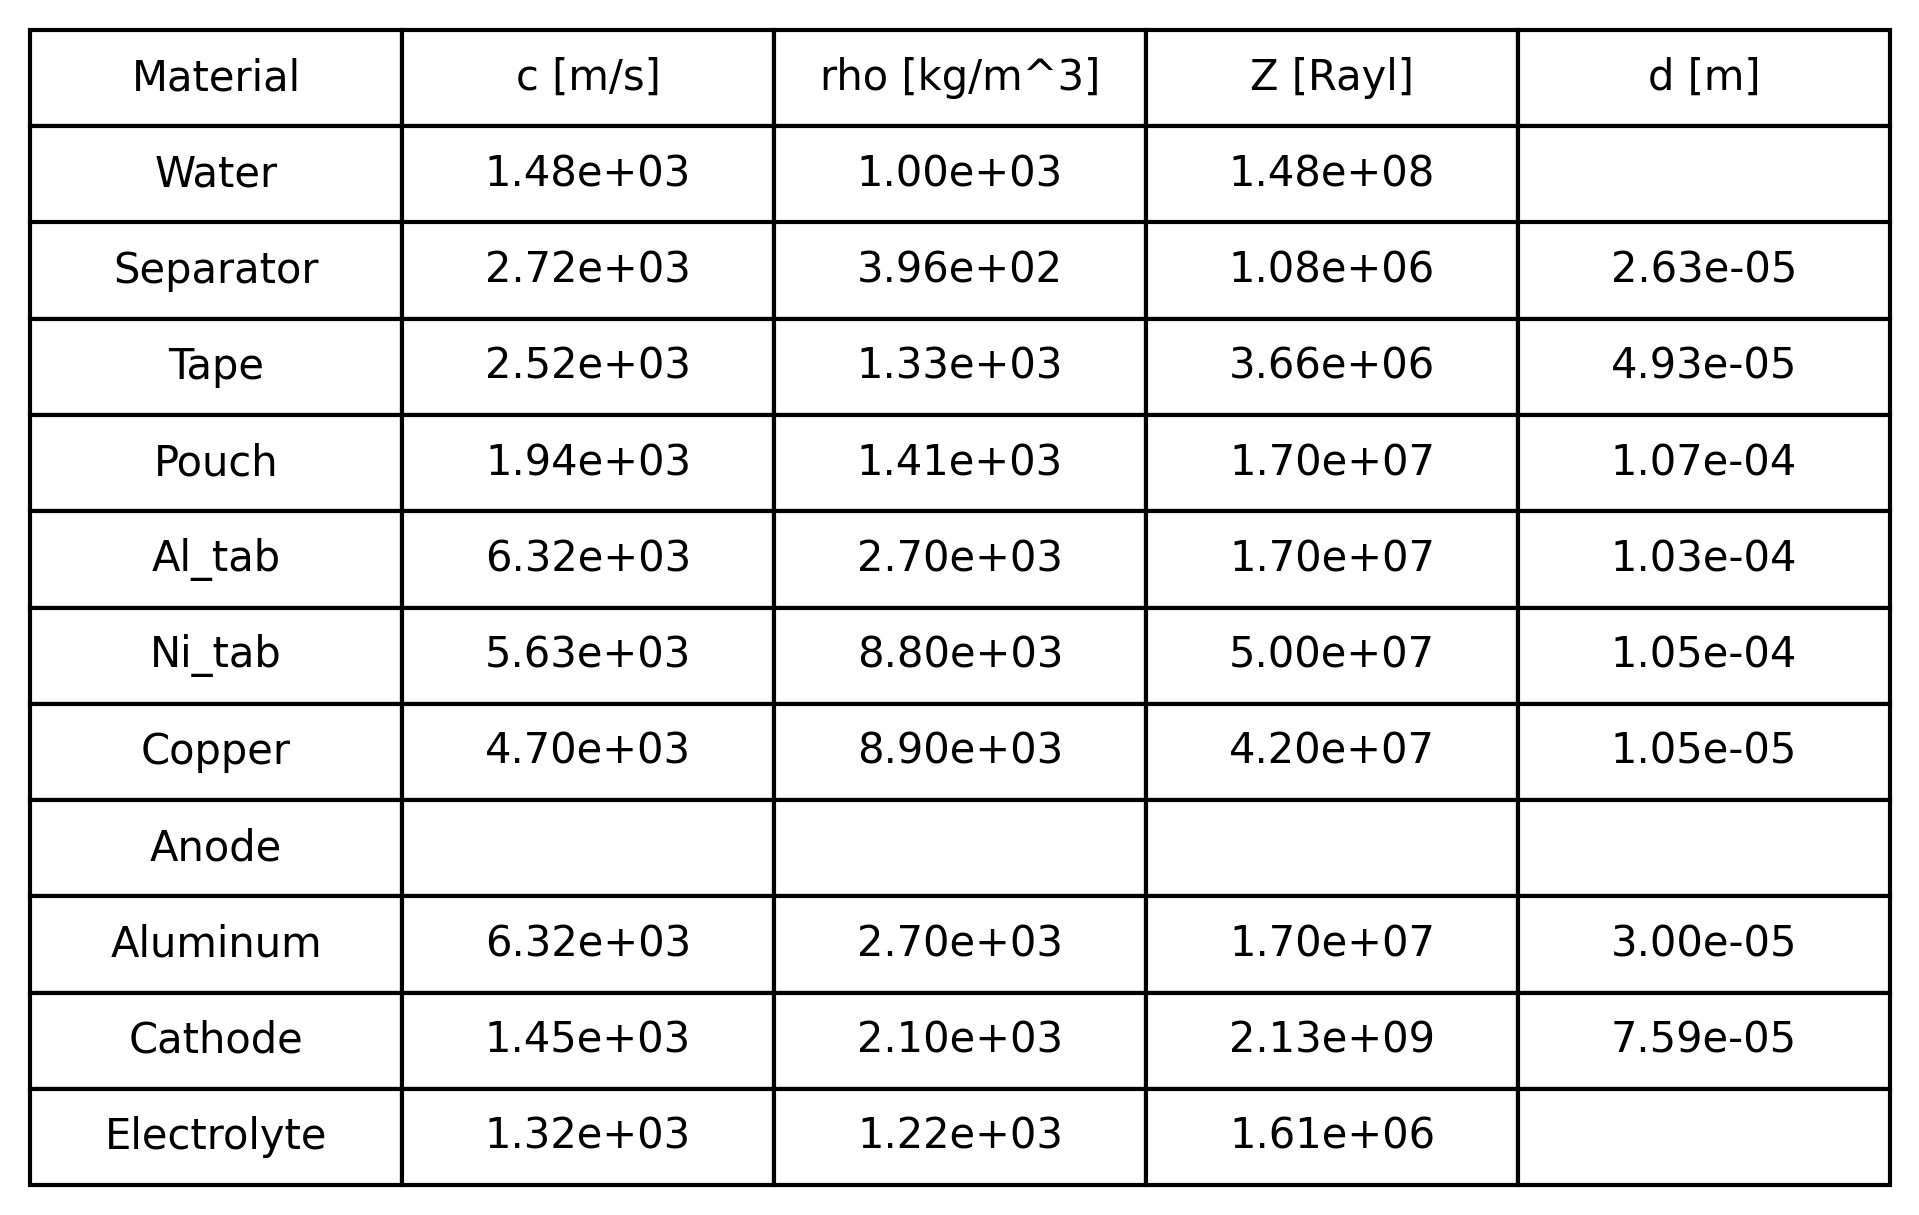

In [18]:
# Create high-resolution figure
fig, ax = plt.subplots(figsize=(8,5), dpi=300)
ax.axis('tight')
ax.axis('off')

# Create table
table_data = params.style.format('{:.2e}', subset=numeric_cols)
# format numeric columns in scientific notation for display
display_df = params.copy()
for c in numeric_cols:
    display_df[c] = display_df[c].apply(lambda x: f"{x:.2e}" if pd.notnull(x) else "")

table = ax.table(cellText=display_df.values, 
                colLabels=display_df.columns,
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])


plt.savefig('params_table.png', dpi=300, bbox_inches='tight');

In [84]:
n = 2
layer_list = ['Cathode',
    'Aluminum',
    'Cathode',
    'Separator',
    'Copper',
    'Separator']

pouch_materials = [
    'Water',
    'Pouch',
    'Tape',
    'Separator',
] + layer_list * n + [
    'Al_tab',
    'Ni_tab',
    'Tape',
    'Pouch',
    'Water'
]
pouch_materials

['Water',
 'Pouch',
 'Tape',
 'Separator',
 'Cathode',
 'Aluminum',
 'Cathode',
 'Separator',
 'Copper',
 'Separator',
 'Cathode',
 'Aluminum',
 'Cathode',
 'Separator',
 'Copper',
 'Separator',
 'Al_tab',
 'Ni_tab',
 'Tape',
 'Pouch',
 'Water']

In [85]:
pouch_rows = []
for material in pouch_materials:
    row = params[params['Material'] == material].iloc[0]
    pouch_rows.append(row)

pouch = pd.DataFrame(pouch_rows)
pouch = pouch.reset_index(drop=True)
pouch.style.format('{:.2e}', subset=numeric_cols)

,Material,c [m/s],rho [kg/m^3],Z [Rayl],d [m]
0,Water,1.48e+03,1.00e+03,1.48e+08,nan
1,Pouch,1.94e+03,1.41e+03,1.70e+07,1.07e-04
2,Tape,2.52e+03,1.33e+03,3.66e+06,4.93e-05
3,Separator,2.72e+03,3.96e+02,1.08e+06,2.63e-05
4,Cathode,1.45e+03,2.10e+03,2.13e+09,7.59e-05
5,Aluminum,6.32e+03,2.70e+03,1.70e+07,3.00e-05
6,Cathode,1.45e+03,2.10e+03,2.13e+09,7.59e-05
7,Separator,2.72e+03,3.96e+02,1.08e+06,2.63e-05
8,Copper,4.70e+03,8.90e+03,4.20e+07,1.05e-05
9,Separator,2.72e+03,3.96e+02,1.08e+06,2.63e-05


# Look at pouch US

## load data

In [114]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFile = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/tomography_toy_data/2_layer_pouch_open.sqlite3'

# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pickle_dict = pj.sqliteToPickle(sqliteFile)

# Load the pickle
pickleFile = os.path.splitext(sqliteFile)[0] + '.pickle'
data = pj.loadPickle(pickleFile)

# data = pj.loadPickle(os.path.split(pickleFiles[0])[0]+'/combined.pickle')
data['parameters']['dt'] = (data['parameters']['measureDelay']-data['parameters']['measureTime']) *10**-6/ data['parameters']['samples']

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/tomography_toy_data/2_layer_pouch_open.pickle already exists. Conversion aborted.


In [307]:
data['parameters']

{'gui': 0.0,
 'experiment': 'single scan',
 'axis': 'z',
 'distance': -75.0,
 'transducerFrequency': 2.25,
 'collectionMode': 'both',
 'pulserType': 'standard',
 'measureTime': 65.0,
 'measureDelay': 40.0,
 'voltageRange': 2.0,
 'autoRange': 'True',
 'autoRangeEcho': 'True',
 'waves': 100.0,
 'samples': 12500.0,
 'halfCycles': 2.0,
 'multiplexer': 'True',
 'collectionDirection': 'both',
 'voltageOffsetForward': 0.0,
 'voltageOffsetReverse': 0.0,
 'gainForward': 500.0,
 'gainReverse': 500.0,
 'picoModule': 1.0,
 'pulseModule': 0.0,
 'rfSwitch': 2.0,
 't0PulseSwitch': 0.0,
 't0ReceiveSwitch': 0.0,
 't1PulseSwitch': 1.0,
 't1ReceiveSwitch': 1.0,
 'experimentFolder': 'C://Users//changlab//Desktop//UT Data//toy_data//',
 'experimentName': '2_layer_pouch_open',
 'experimentBaseName': 'test_multiscan_data',
 'saveFormat': 'sqlite',
 'postAnalysis': 'False',
 'primaryAxis': 'X',
 'secondaryAxis': 'Z',
 'primaryAxisRange': 40.0,
 'primaryAxisStep': 1.0,
 'secondaryAxisRange': 25.0,
 'secondaryA

In [87]:
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
waveform_df.columns

Index(['voltage_transmission_forward', 'voltage_echo_forward',
       'voltage_transmission_reverse', 'voltage_echo_reverse',
       'voltageOffsetForward', 'gainForward', 'voltageOffsetReverse',
       'gainReverse', 'time', 'time_collected', 'collection_index', 'X', 'Z'],
      dtype='str')

## preprocess

In [88]:
from scipy.signal import butter, sosfiltfilt
from scipy.optimize import curve_fit
waveform_keys = ['voltage_transmission_forward','voltage_echo_forward', 'voltage_transmission_reverse', 'voltage_echo_reverse']
idx=0

# background subtraction and gain correction
try:
    data_cleaned = waveform_df.copy()
except:
    for c in waveform_keys:
        data_cleaned[c] = waveform_df[c]

sos = butter(5, 1000000, btype = 'highpass', analog = False, fs = 500000000, output = 'sos')

data_cleaned['voltage_transmission_forward'] = list(map(pj.correctVoltageByGain, data_cleaned['voltage_transmission_forward'], data_cleaned['voltageOffsetForward'] / 10))
data_cleaned['voltage_echo_forward'] = list(map(pj.correctVoltageByGain, data_cleaned['voltage_echo_forward'], data_cleaned['voltageOffsetForward'] / 10))

data_cleaned['voltage_transmission_reverse'] = list(map(pj.correctVoltageByGain, data_cleaned['voltage_transmission_reverse'], data_cleaned['voltageOffsetReverse'] / 10))
data_cleaned['voltage_echo_reverse'] = list(map(pj.correctVoltageByGain, data_cleaned['voltage_echo_reverse'], data_cleaned['voltageOffsetReverse'] / 10))

for k in waveform_keys:
    data_cleaned[k] = list(map(sosfiltfilt, [sos] * len(data_cleaned), data_cleaned[k]))   


In [89]:
# get stats
for k in waveform_keys:    
    data_cleaned['abs_max_'+k] = list(map(lambda x: np.max(np.abs(x)), data_cleaned[k]))
    data_cleaned['std_'+k] = list(map(np.std, data_cleaned[k]))
    data_cleaned['Hilbert_env'+k] = list(map(pj.hilbertEnvelope, data_cleaned[k]))

In [90]:
# waveforms
crop = [1000, 5000]
dimensions = (
    int(abs(data['parameters']['primaryAxisRange'] / data["parameters"]["primaryAxisStep"]) + 1),
    int(abs(data['parameters']['secondaryAxisRange'] / data["parameters"]["secondaryAxisStep"]) + 1) )

max_value = np.stack([data_cleaned['abs_max_'+k].values for k in waveform_keys]).max()
std_ = np.stack([data_cleaned['std_'+k].values for k in waveform_keys])

In [244]:

def plot_img_waveforms(x, z, t):
    idx = dimensions[0]*z + x

    # Create figure with GridSpec
    fig = plt.figure(figsize=(8, 8), dpi=300)
    gs = fig.add_gridspec(  3, 2, height_ratios=[1, 1, 1.5], hspace=0.3,  wspace=0.2 )

    # Top four image axes
    ax = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, :])  # bottom waveform spans both columns
    ]

    fig.suptitle( f'({abs(x*data["parameters"]["primaryAxisStep"])}, {abs(z*data["parameters"]["secondaryAxisStep"])}) @ {data_cleaned.loc[idx,"time"][t]} ns')

    # images
    for i, k in enumerate(waveform_keys):
        dat = np.stack(data_cleaned[k].values)[..., t].reshape( dimensions[1], dimensions[0] )

        envelope = np.stack(data_cleaned['Hilbert_env'+k].values)[..., t].reshape(dimensions[1], dimensions[0])
        a = ax[i].imshow(envelope)
        fig.colorbar(a, ax=ax[i], shrink=0.6)
        ax[i].set_title(k)
        ax[i].scatter(
            x, z,
            marker='o',
            s=(6*72/ax[i].get_window_extent().width *
               ax[i].get_xlim()[1])**2,
            facecolors='none',
            edgecolors='r',
            linewidths=1
        )

        # waveform plot
        line = ax[4].plot(
            data_cleaned.loc[idx, 'time'][crop[0]:crop[1]],
            data_cleaned.loc[idx, k][crop[0]:crop[1]],
            label=k )[0]
        ax[4].plot(
            data_cleaned.loc[idx, 'time'][crop[0]:crop[1]],
            data_cleaned.loc[idx, 'Hilbert_env'+k][crop[0]:crop[1]],
            color= line.get_color(),
            linestyle='--',
            linewidth=1
        )

    # time marker
    ax[4].axvline(
        data_cleaned.loc[idx, 'time'][t],
        color='r',
        linestyle='--'
    )

    ax[4].set_xlabel('Time (ns)')
    ax[4].set_ylabel('Voltage (mV)')
    ax[4].set_ylim(-max_value, max_value)

    ax[4].legend(
        handles=ax[4].get_lines()[::2],
        labels=waveform_keys,
        loc='upper right'
    )

    fig.tight_layout()

In [245]:
import warnings

warnings.filterwarnings("ignore")

In [246]:
x_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=dimensions[0]-1,
    step=1,
    description='X:',
    continuous_update=False
)

z_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=dimensions[1]-1,
    step=1,
    description='Z:',
    continuous_update=False
)
t_slider = widgets.IntSlider(
    value=2600,
    min=crop[0],
    max=crop[1],
    step=10,
    description='t:',
    continuous_update=False
)

interact(plot_img_waveforms, x=x_slider, z=z_slider, t=t_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='X:', max=40), IntSlider(value=0…

<function __main__.plot_img_waveforms(x, z, t)>

## amp and tof

In [92]:
def noise_floor_envelope_tof(y_dat,x_dat):
    env = pj.hilbertEnvelope(y_dat)    
    firstBreakIndex = pj.firstIndexAboveNoise(env)
    return x_dat[firstBreakIndex]

In [93]:
# get amp, hilbert tof
for k in waveform_keys:    
    data_cleaned['amplitude_'+k+'(mV)'] = list(map(pj.maxMinusMin, data_cleaned[k]))
    data_cleaned['Hilbert_ToF_'+k+' (ns)'] = list(map(noise_floor_envelope_tof, data_cleaned[k], data_cleaned['time']))

In [593]:
# # plot amplitude
# fig, ax = plt.subplots(2, 2, figsize=(8, 6))
# ax = ax.flatten()
# fig.suptitle('Peak to valley Amplitude (mV)')

# for i, k in enumerate(waveform_keys):
#     a = ax[i].imshow(data_cleaned['amplitude_'+k+'(mV)'].values.reshape(dimensions[1], dimensions[0]))
#     fig.colorbar(a, ax=ax[i], shrink=0.6)
#     ax[i].set_title(f'{k}')
    
# fig.tight_layout()

In [594]:
# for idx in range(0,dimensions[0]*dimensions[1],53):
#     plt.clf()
#     plt.plot(data_cleaned['time'][idx][1000:5000], data_cleaned[k][idx][1000:5000])
#     plt.plot(data_cleaned['time'][idx][1000:5000], data_cleaned['Hilbert_env'+k][idx][1000:5000], linestyle='--')
#     plt.axvline(data_cleaned['Hilbert_ToF_'+k+' (ns)'][idx], -200, 200, color='r', linestyle='--')
#     plt.show()

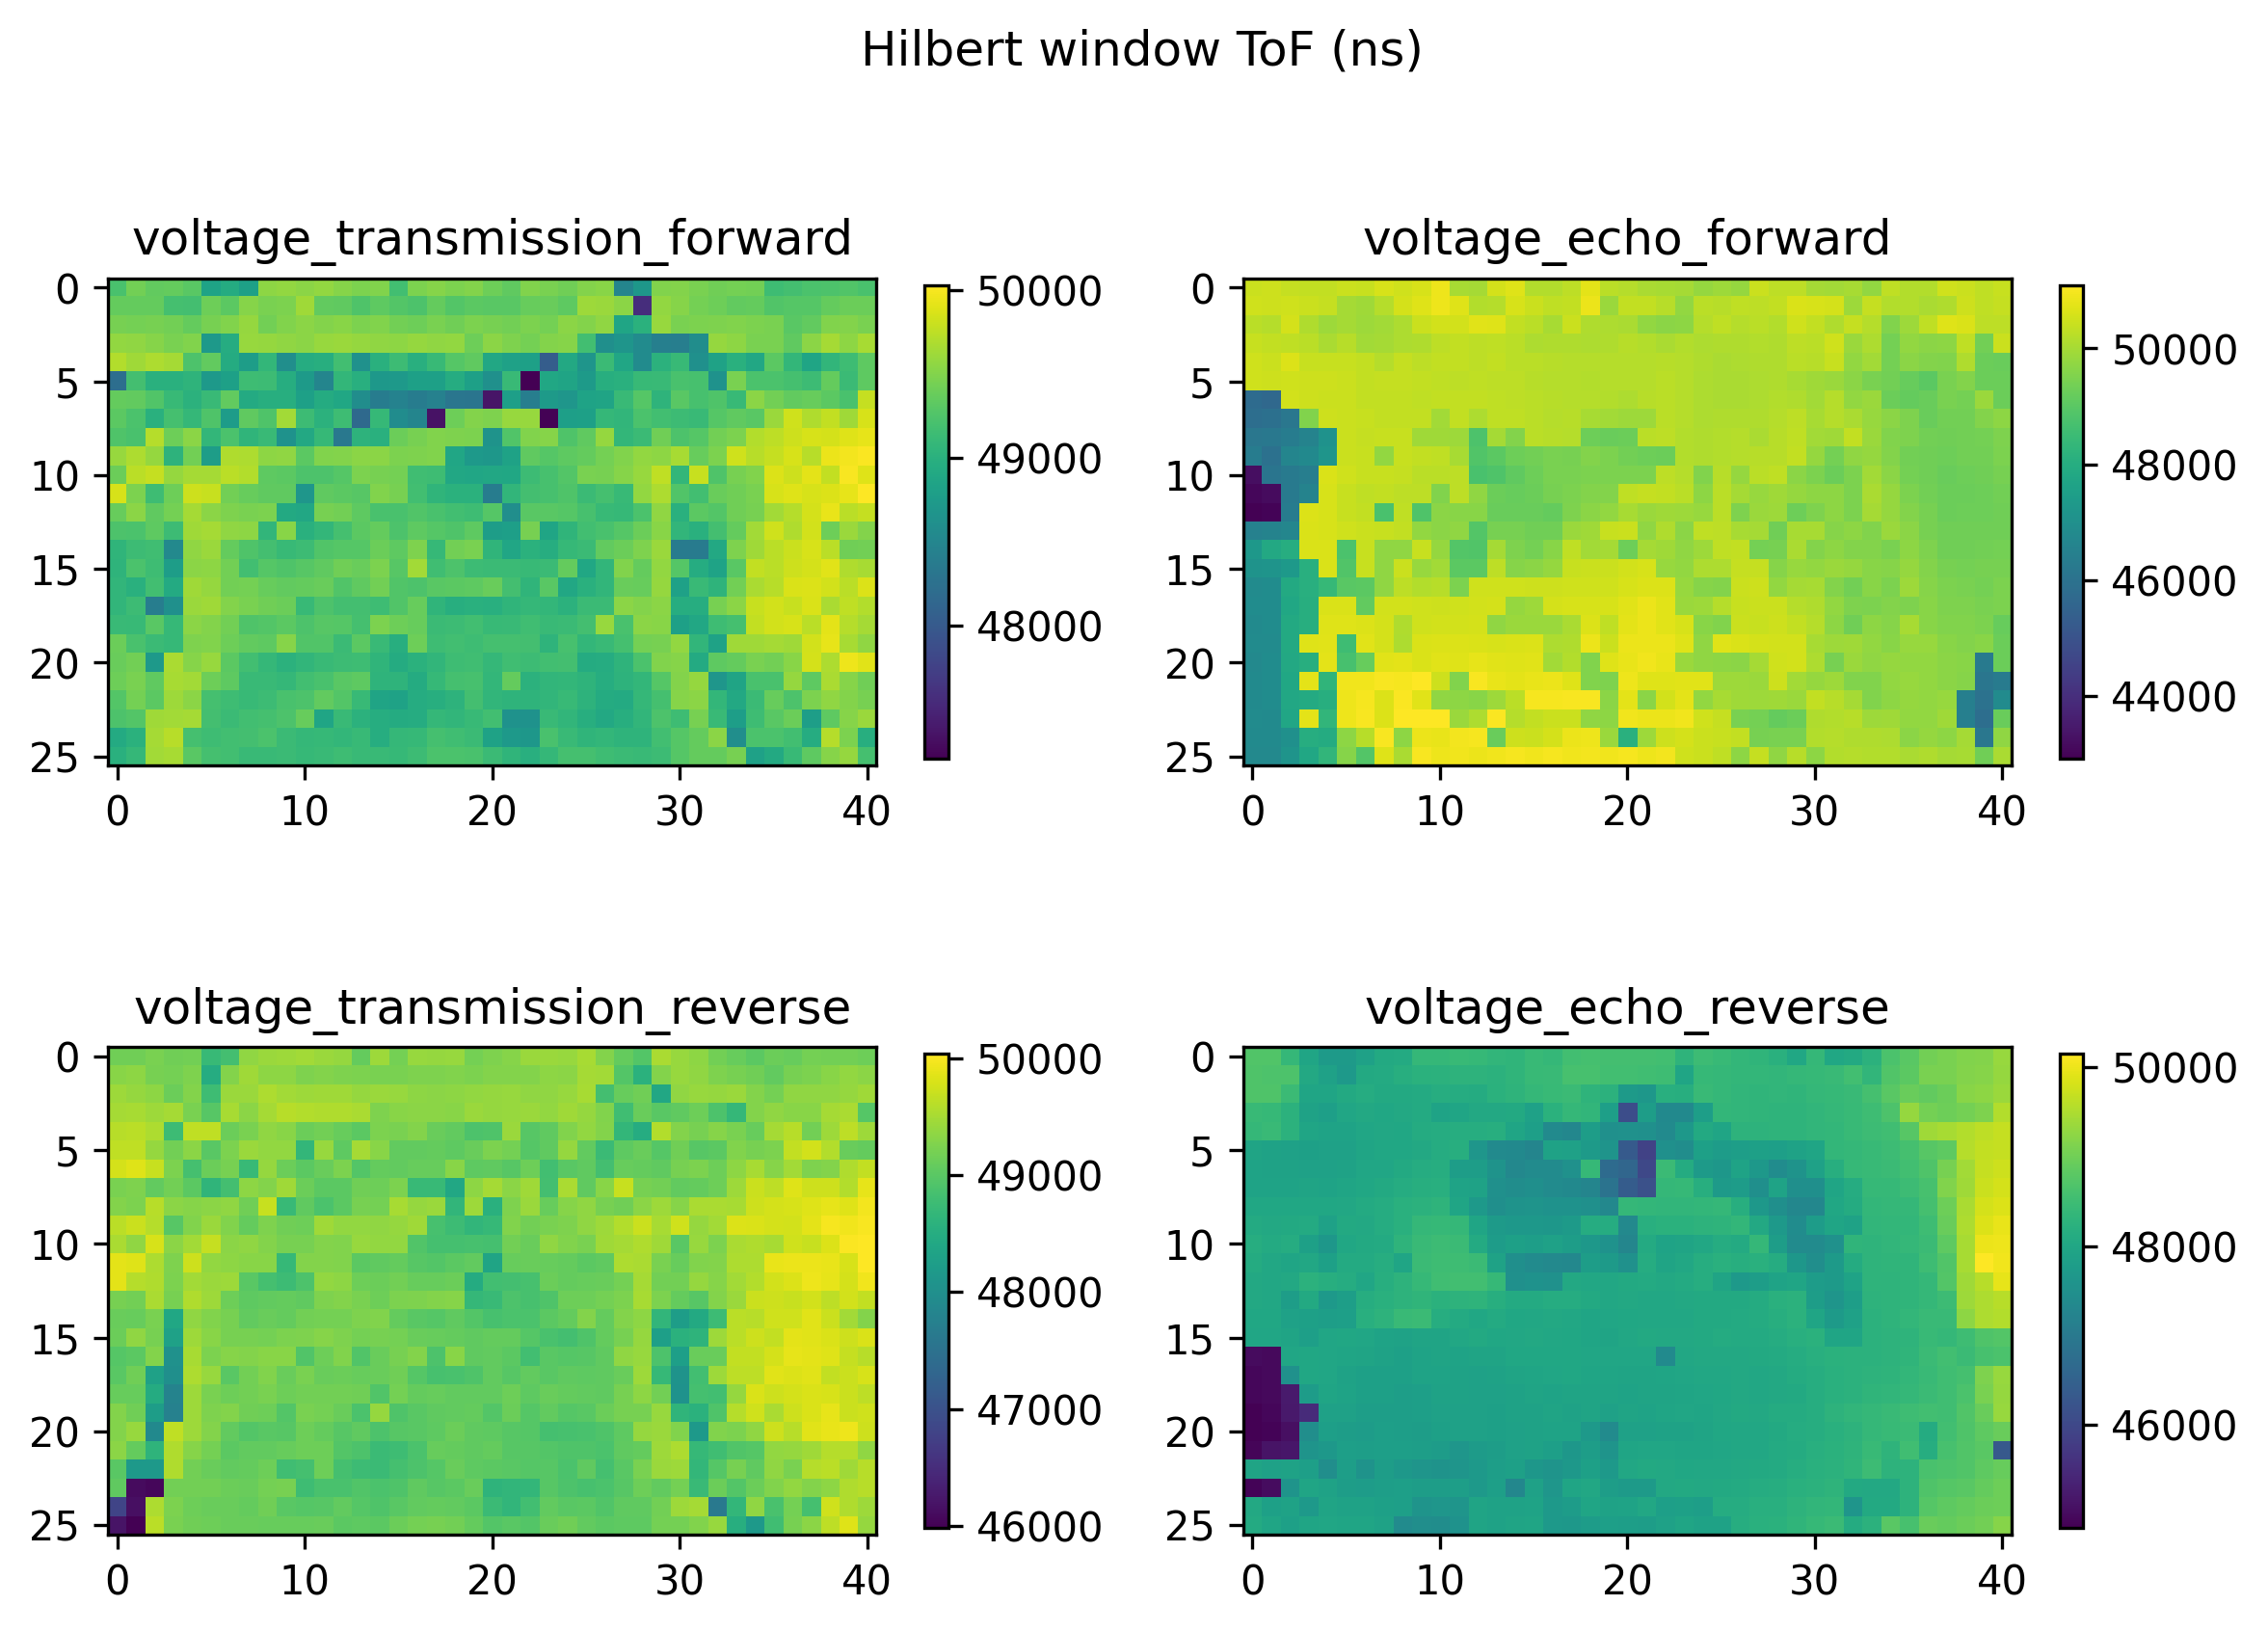

In [595]:
# plot tof
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax = ax.flatten()
fig.suptitle('Hilbert window ToF (ns)')

for i, k in enumerate(waveform_keys):
    a = ax[i].imshow(data_cleaned['Hilbert_ToF_'+k+' (ns)'].values.reshape(dimensions[1],dimensions[0]))
    fig.colorbar(a, ax=ax[i], shrink=0.6)
    ax[i].set_title(f'{k}')
    
fig.tight_layout()

## basic distances

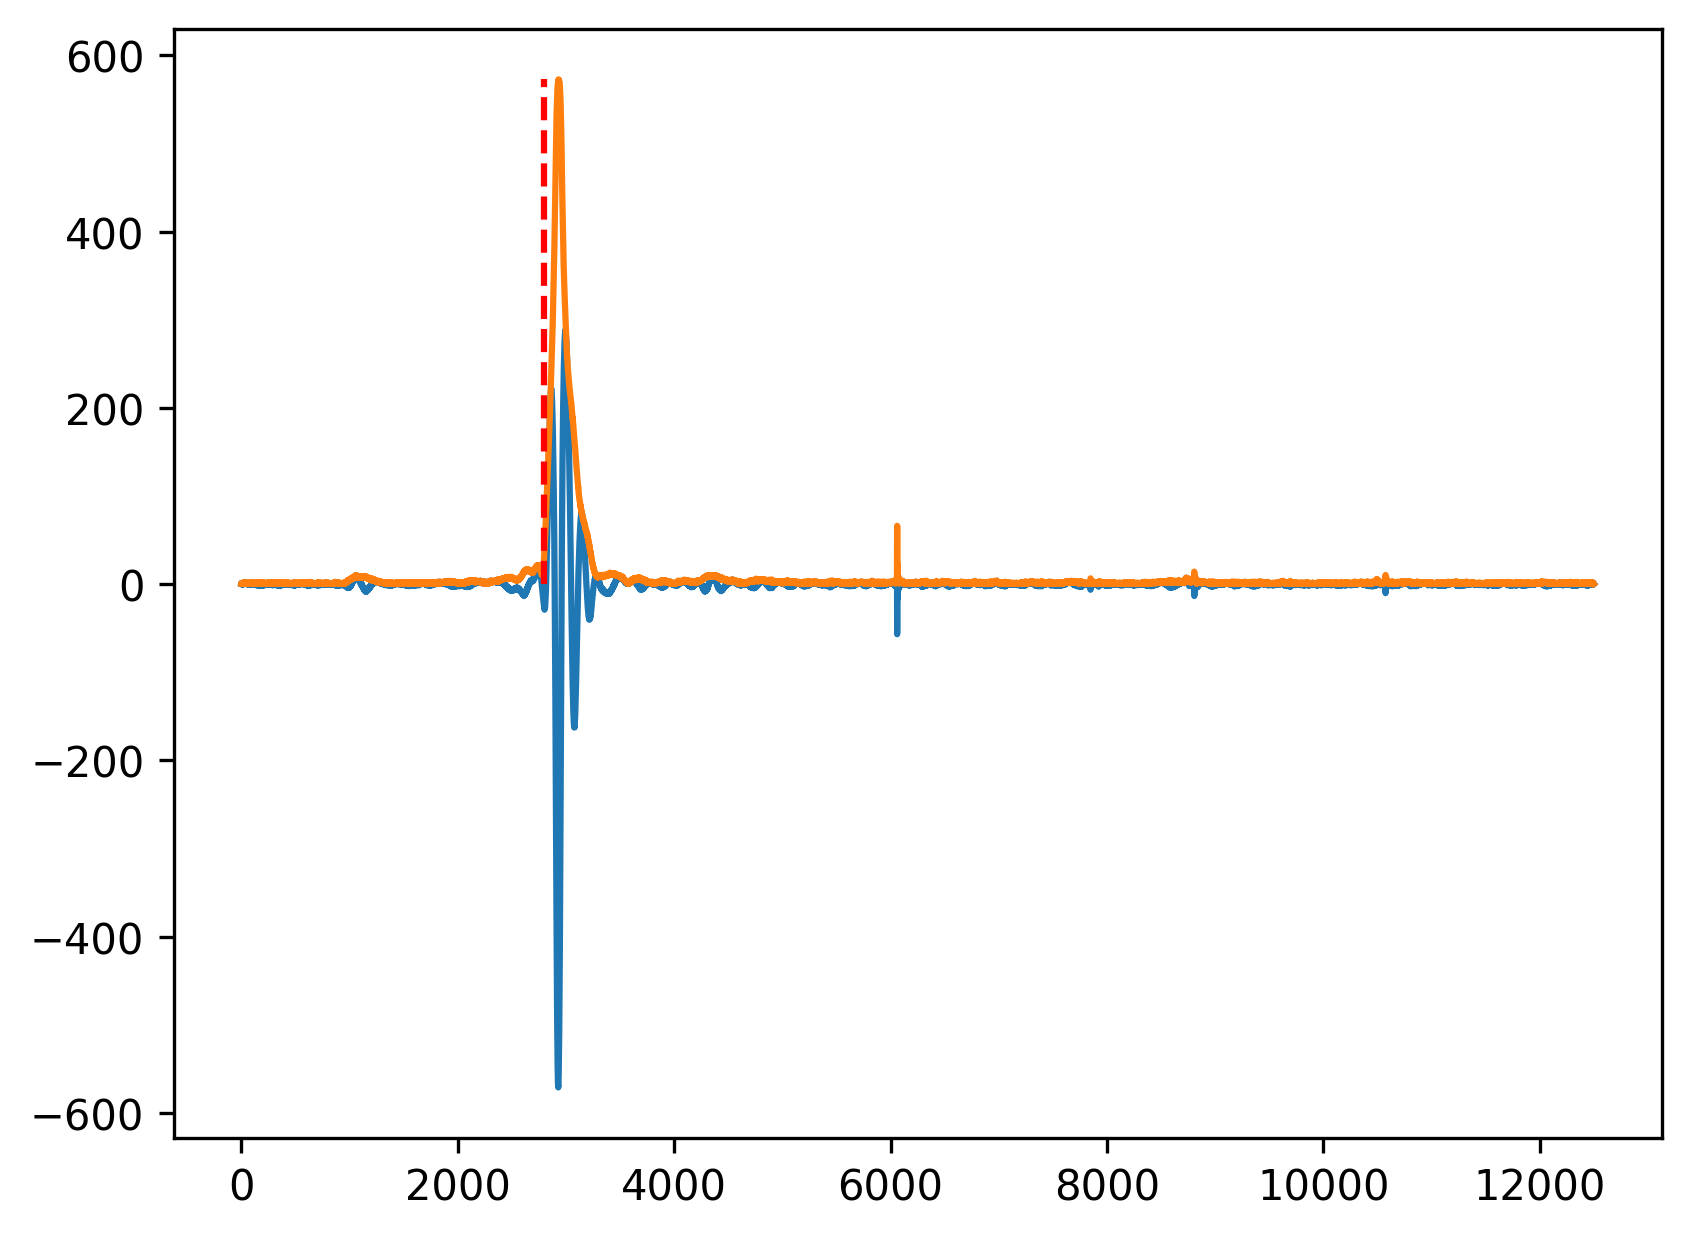

In [586]:
k = waveform_keys[1]
dat = data_cleaned[k][0.0]
env = pj.hilbertEnvelope(dat)    
firstBreakIndex = pj.firstIndexAboveNoise(env)

plt.plot(dat)
plt.plot(env)
plt.vlines(firstBreakIndex, ymin=0, ymax=np.max(env), color='r', linestyle='--', label='First Break Index')

In [94]:
# tof and distance through water
c = params.loc[params['Material'] == 'Water', 'c [m/s]'].values

data_cleaned['d_water_forward (m)'] = data_cleaned['Hilbert_ToF_voltage_echo_forward (ns)'] * 1e-9 * c / 2
data_cleaned['d_water_reverse (m)'] = data_cleaned['Hilbert_ToF_voltage_echo_reverse (ns)'] * 1e-9 * c / 2

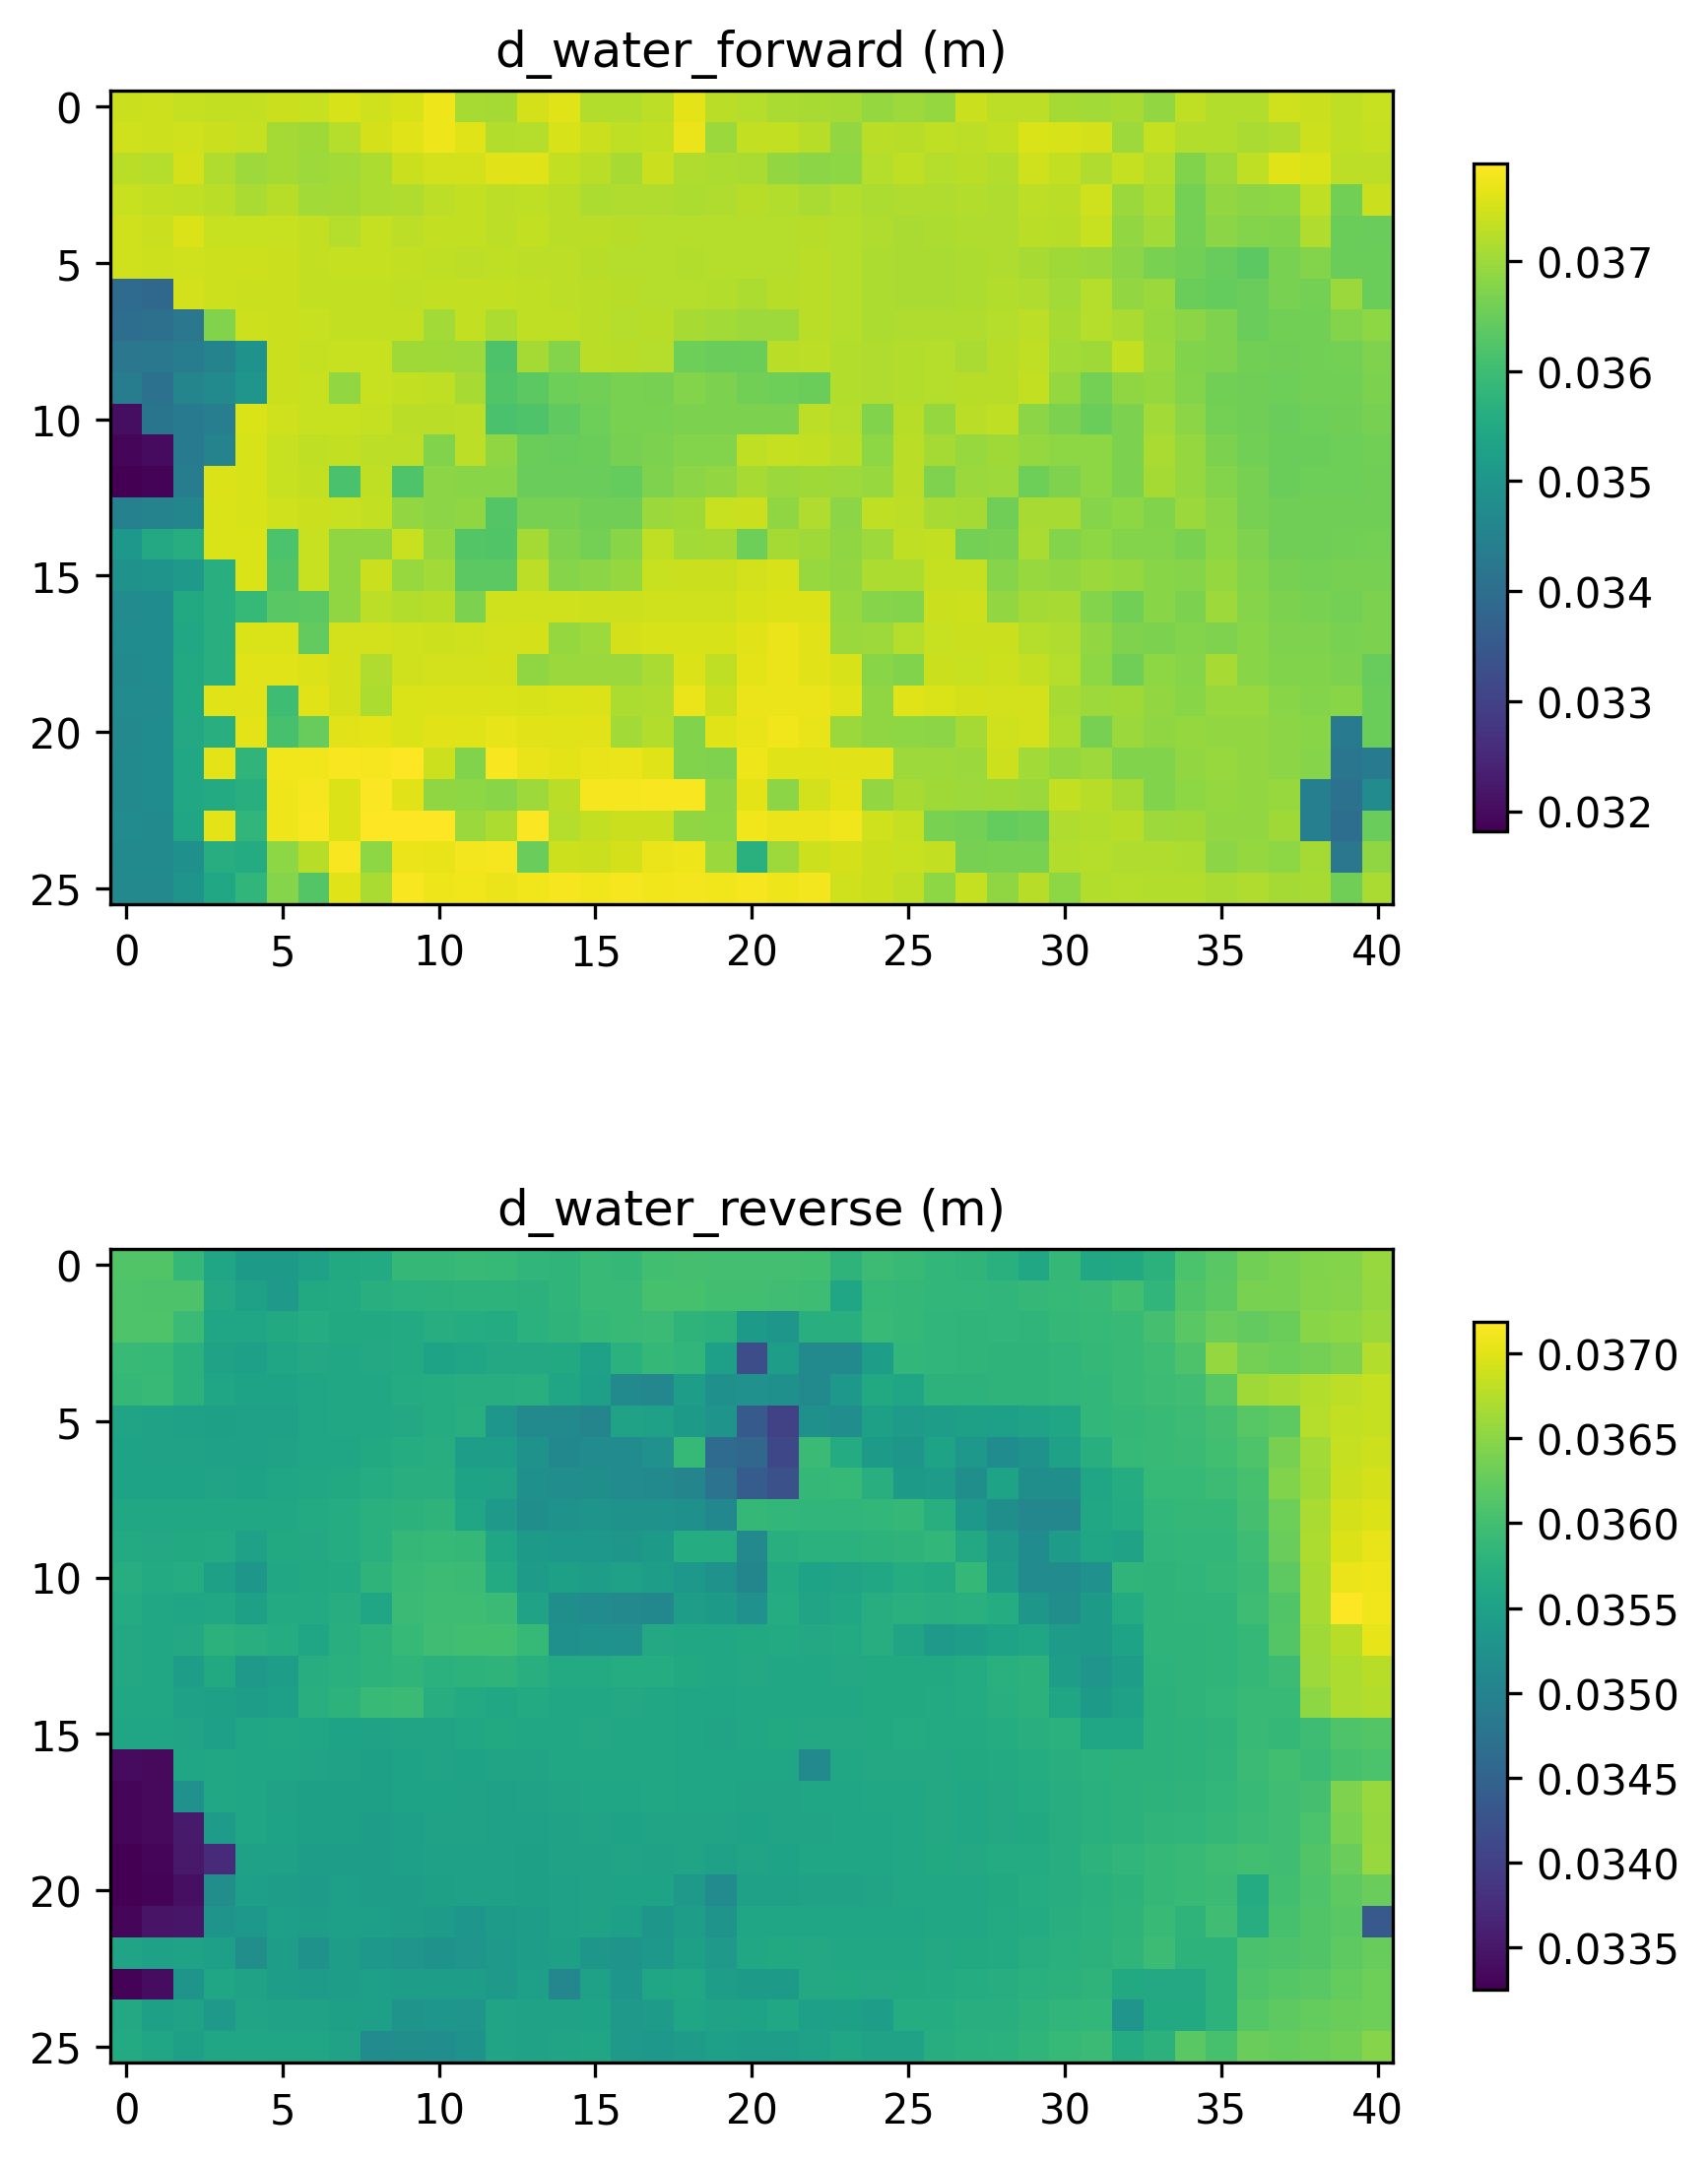

In [607]:
# plot thickness
# plot tof

fig, ax = plt.subplots(2,figsize=(6,8))
for i, k in enumerate(['d_water_forward (m)', 'd_water_reverse (m)']):
    ax[i].set_title(f'{k}')
    a = ax[i].imshow(data_cleaned[k].values.reshape(dimensions[1], dimensions[0]))
    fig.colorbar(a, ax=ax[i], shrink=0.6)
    
fig.tight_layout()

In [95]:
# pouch tof
data_cleaned['tof_pouch_forward (ns)'] = data_cleaned['Hilbert_ToF_voltage_transmission_forward (ns)'] - (data_cleaned['Hilbert_ToF_voltage_echo_forward (ns)'] + data_cleaned['Hilbert_ToF_voltage_echo_reverse (ns)'])/2
data_cleaned['tof_pouch_reverse (ns)'] = data_cleaned['Hilbert_ToF_voltage_transmission_reverse (ns)'] - (data_cleaned['Hilbert_ToF_voltage_echo_forward (ns)'] + data_cleaned['Hilbert_ToF_voltage_echo_reverse (ns)'])/2


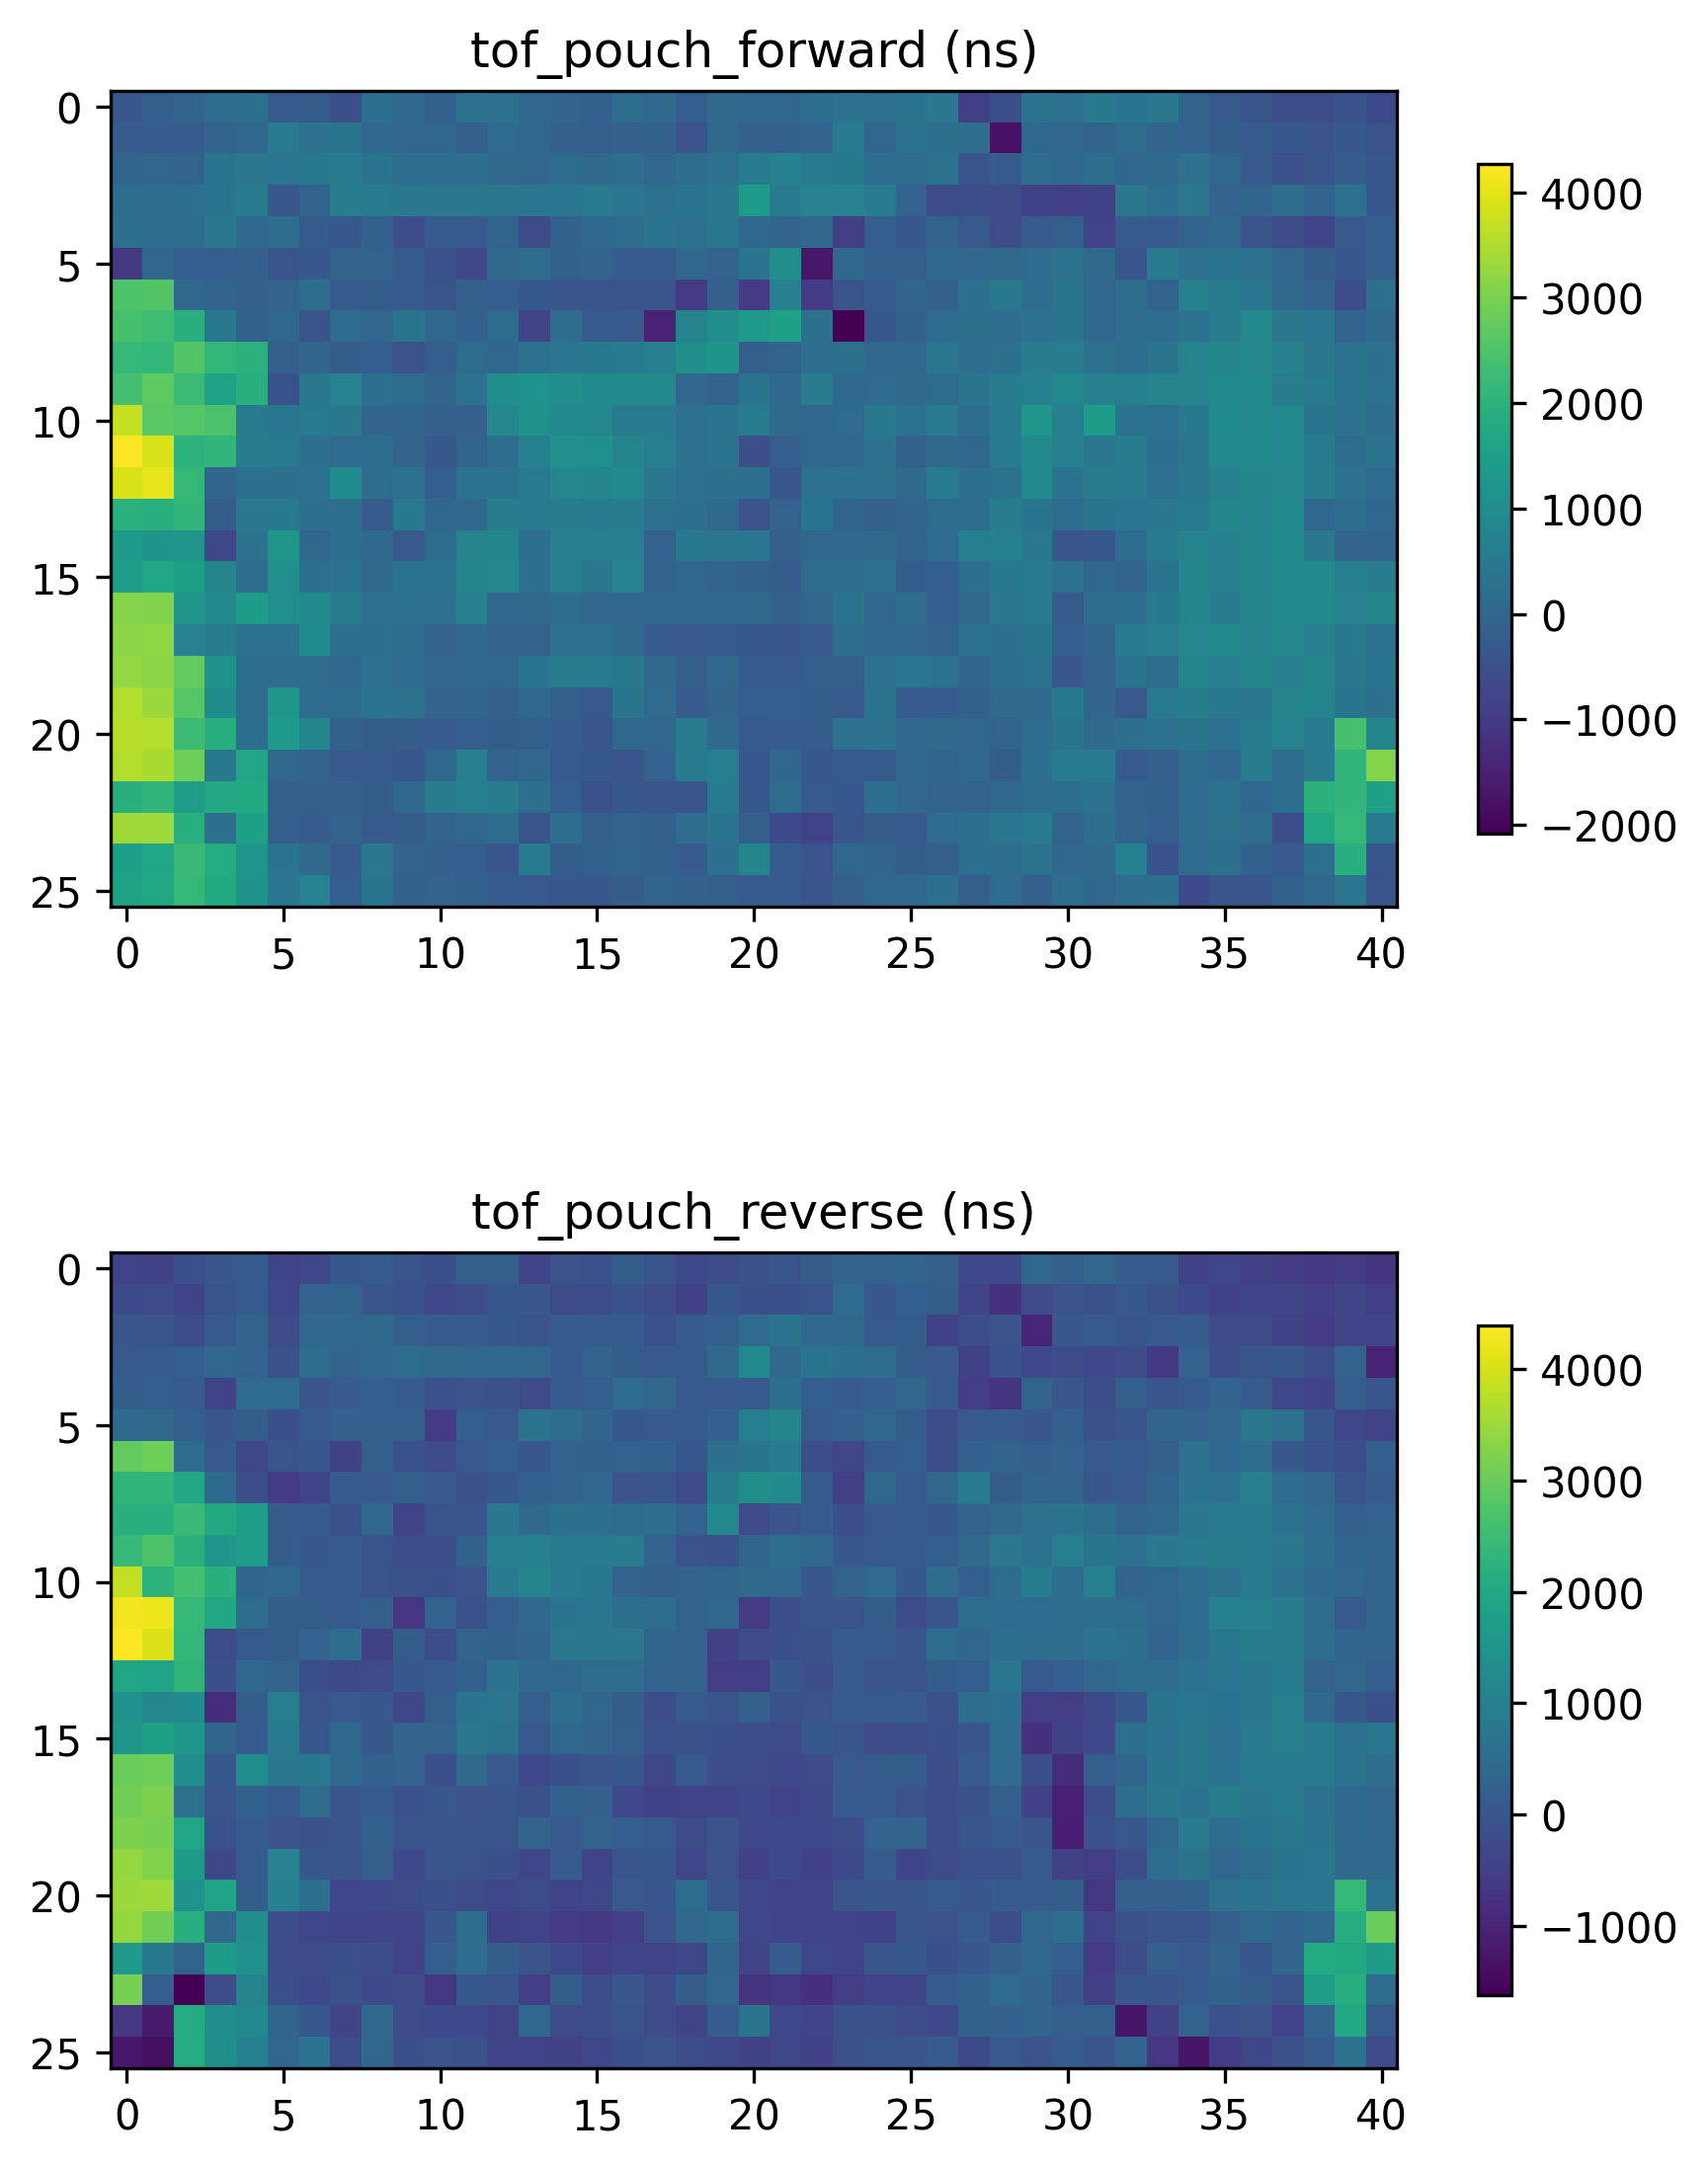

In [615]:
# plot thickness
# plot tof

fig, ax = plt.subplots(2,figsize=(6,8))
for i, k in enumerate(['tof_pouch_forward (ns)', 'tof_pouch_reverse (ns)']):
    ax[i].set_title(f'{k}')
    a = ax[i].imshow(data_cleaned[k].values.reshape(dimensions[1], dimensions[0]))
    fig.colorbar(a, ax=ax[i], shrink=0.6)
    
fig.tight_layout()

In [96]:
# pouch d
data_cleaned['d_pouch_calculated (mm)'] = 75 - (data_cleaned['d_water_forward (m)'] + data_cleaned['d_water_reverse (m)'])*1000


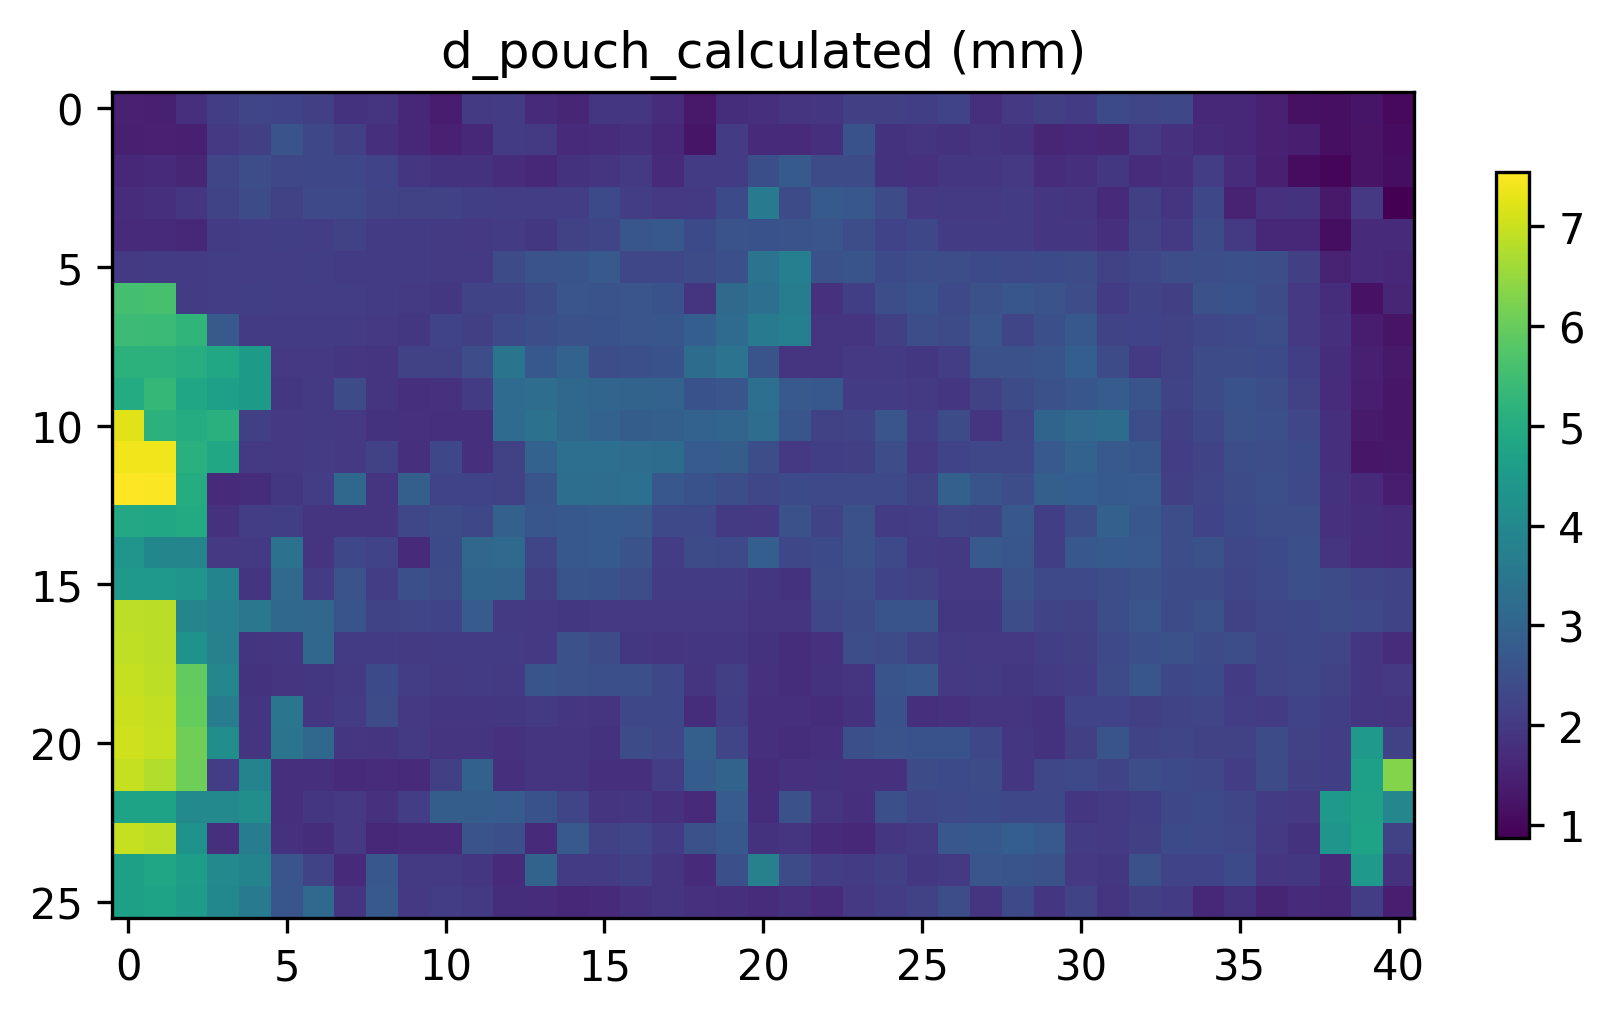

In [614]:
# plot thickness

fig, ax = plt.subplots(figsize=(6, 4))
k='d_pouch_calculated (mm)'
ax.set_title(f'{k}')
a = ax.imshow(data_cleaned[k].values.reshape(dimensions[1], dimensions[0]))
fig.colorbar(a, ax=ax, shrink=0.6)

fig.tight_layout()

# tmm

Normal-incidence acoustic transfer-matrix method (TMM), structured to match
the conventions of sbyrnes321/tmm (https://github.com/sbyrnes321/tmm).

tmm.coh_tmm() is derived for EM optics, where a single complex index $n_j$
  sets BOTH the phase velocity $(v = c/n)$ AND the wave impedance
  $(Z_opt = Z_0/n)$ for a non-magnetic medium -- the two are reciprocally
  linked through the same n.

In acoustics the two quantities are independent:
      - phase speed      $c_j$        (sets the propagation constant $k_j = \omega /c_j$)
      - characteristic impedance   $Z_j = \rho_j * c_j$   (sets the reflection/
                                                        transmission at interfaces)

  $\rho$ and c vary independently between materials, so they can't be folded
  into one optical "n". Instead this module builds the acoustic analogue of
  tmm's coherent 2x2 transfer-matrix product directly from $(\rho, c)$ per
  layer, using the same layer-stack / d_list / matrix-product architecture
  as tmm_core.coh_tmm.

**Sign/units convention:** pressure & volume-velocity transfer matrix

$$
\begin{bmatrix} P_0 \\ U_0 \end{bmatrix}
=
\begin{bmatrix} M_{11} & M_{12} \\ M_{21} & M_{22} \end{bmatrix}
\begin{bmatrix} P_{N+1} \\ U_{N+1} \end{bmatrix}
$$

For each layer $j$ (thickness $d_j$, $k_j = \dfrac{2\pi f}{c_j}$, $Z_j = \rho_j c_j$):

$$
M_j =
\begin{bmatrix}
\cos(k_j d_j) & i\, Z_j \sin(k_j d_j) \\[4pt]
\dfrac{i \sin(k_j d_j)}{Z_j} & \cos(k_j d_j)
\end{bmatrix}
$$

Total matrix (front to back, same ordering `tmm` uses for its characteristic-matrix product):

$$
M = M_1 \cdot M_2 \cdot \, \dots \, \cdot M_N
$$

Reflection/transmission for a stack immersed between semi-infinite fluids $Z_0$ (incident) and $Z_L$ (exit):

$$
r = \frac{M_{11} Z_L + M_{12} - M_{21} Z_0 Z_L - M_{22} Z_0}
         {M_{11} Z_L + M_{12} + M_{21} Z_0 Z_L + M_{22} Z_0}
$$

$$
t = \frac{2 Z_L}
         {M_{11} Z_L + M_{12} + M_{21} Z_0 Z_L + M_{22} Z_0}
$$

Power coefficients:

$$
R = |r|^2 \qquad\qquad T = \frac{Z_0}{Z_L}\,|t|^2 \quad \text{(real } Z_0, Z_L\text{)}
$$

--------------------------------------------------------------------------
Per-pixel usage
--------------------------------------------------------------------------
From your waveform analysis at pixel (i, j) you'd have, per POSITION in
the stack (not per name):
  - present_ij[k]   : bool, is layer k physically present at this pixel
  - d_local_ij[k]   : locally measured thickness for layer k (NaN/None if
                     you don't have a local measurement -> falls back to
                     the table's nominal d)

Example: tabs (positions 16, 17) absent at this pixel, and the FIRST
separator (position 3) measured locally thinner than nominal -- note this
does NOT affect the other 4 separator occurrences, because we're indexing
by position:

In [ ]:
from 

In [190]:
pouch

,Material,c [m/s],rho [kg/m^3],Z [Rayl],d [m]
0,Water,1483.000000,1000.000000,1.480000e+08,NaN
1,Pouch,1942.000000,1406.000000,1.700000e+07,0.000107
2,Tape,2520.000000,1327.586207,3.662500e+06,0.000049
3,Separator,2715.118291,396.000000,1.075187e+06,0.000026
4,Cathode,1447.000000,2100.000000,2.125728e+09,0.000076
5,Aluminum,6320.000000,2700.000000,1.700000e+07,0.000030
6,Cathode,1447.000000,2100.000000,2.125728e+09,0.000076
7,Separator,2715.118291,396.000000,1.075187e+06,0.000026
8,Copper,4700.000000,8900.000000,4.200000e+07,0.000010
9,Separator,2715.118291,396.000000,1.075187e+06,0.000026


In [194]:
# at a single pixel, we can build the stack matrix and get R/T
f0 = 2.25e6  # Hz
idx = 0
layer_props_ij = pouch.copy()
layer_props_ij.loc[0, 'd [m]'] = data_cleaned['d_water_forward (m)'][idx]
layer_props_ij.loc[20, 'd [m]'] = data_cleaned['d_water_reverse (m)'][idx]
layer_props_ij = layer_props_ij.to_dict(orient='records')

present_ij = [True] * len(pouch)
present_ij[16] = False  # example: layer 16 is missing at this pixel
present_ij[17] = False  # example: layer 17 is missing at this pixel

M_ij = build_stack_matrix(layer_props_ij, present_ij, f0)
M_ij

array([[-0.50996427+0.00000000e+00j,  0.        -1.10555447e+06j],
       [ 0.        -6.48844364e-07j, -0.55428827+0.00000000e+00j]])

In [198]:
rho_list = [layer['rho [kg/m^3]'] for layer in layer_props_ij]
c_list = [layer['c [m/s]'] for layer in layer_props_ij]
d_list = [layer['d [m]'] for layer in layer_props_ij]

stack_dict, M_ij = acoustic_tmm_layers(rho_list, c_list, d_list, f0)

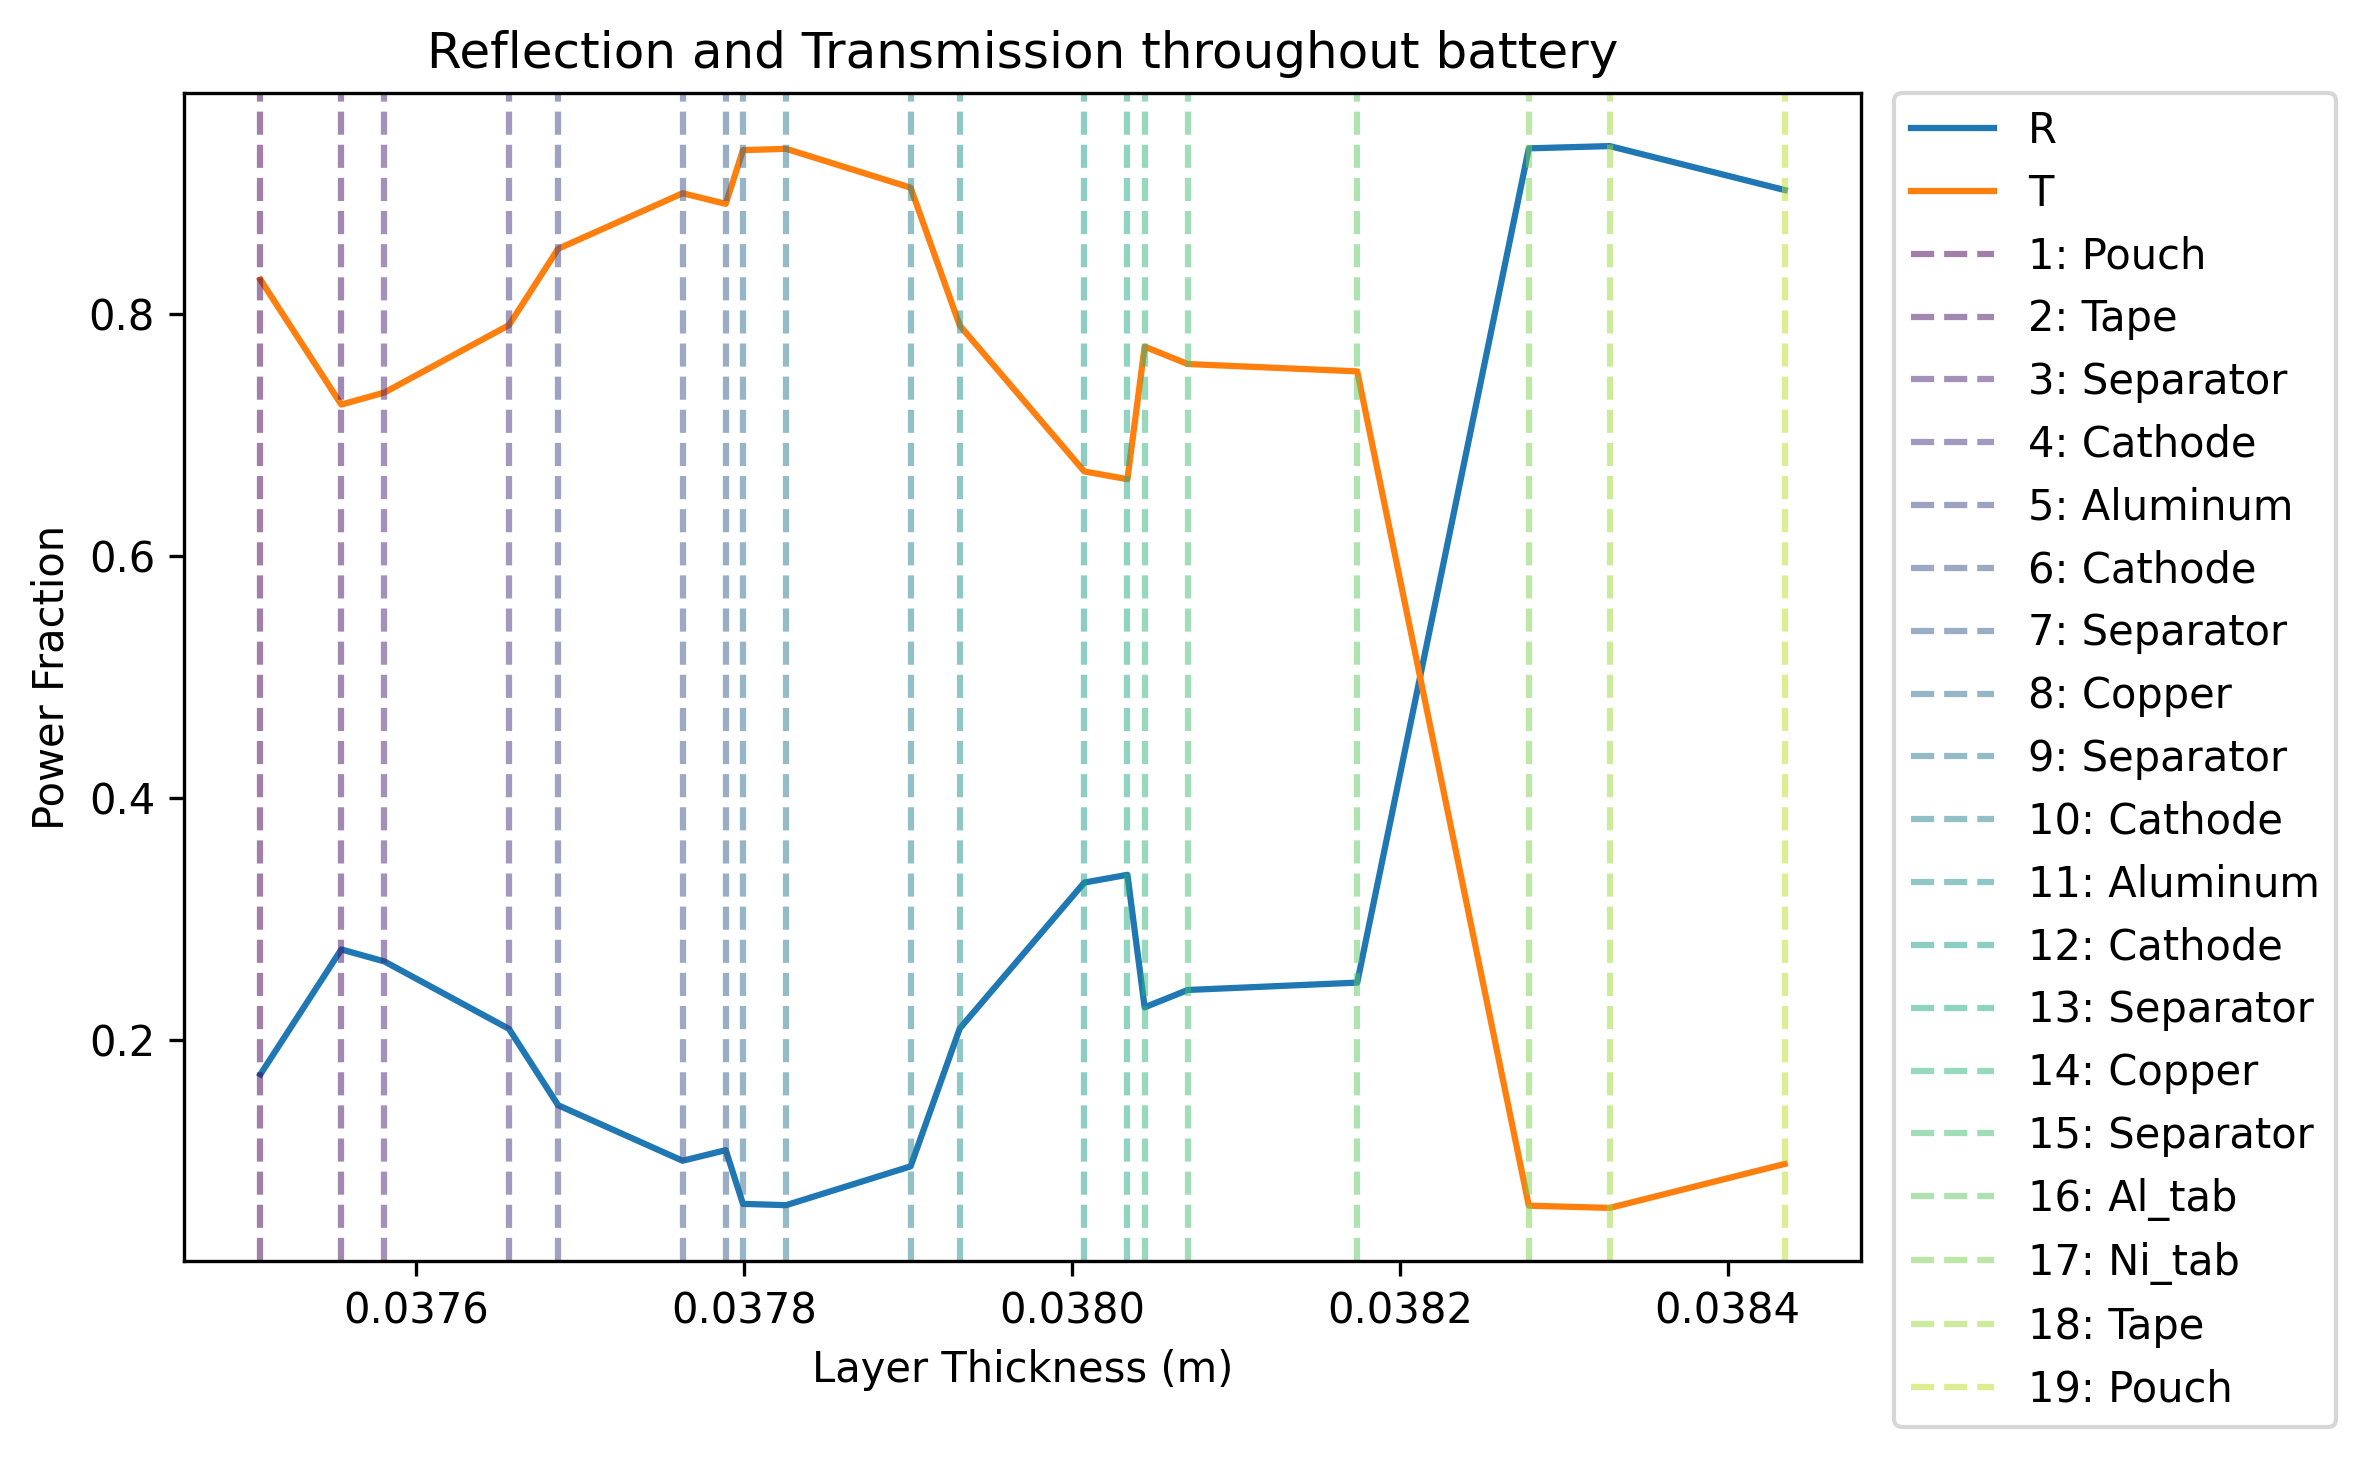

In [237]:
d_list_cumsum = np.cumsum(d_list)  # cumulative thicknesses, including incident and exit media
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(d_list_cumsum[1:-1], stack_dict['R'], label='R')
plt.plot(d_list_cumsum[1:-1], stack_dict['T'], label='T')
colors = cm.viridis(np.linspace(0, 1, len(layer_props_ij)))
for i, d in enumerate(d_list_cumsum[1:-1]):
    plt.axvline(d, color=colors[i], linestyle='--', alpha=0.5, label=f'{i+1}: {layer_props_ij[i+1]["Material"]}')
plt.xlabel('Layer Thickness (m)')
plt.ylabel('Power Fraction')
plt.title('Reflection and Transmission throughout battery')
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0
)
plt.tight_layout()

In [220]:
f_center = 2.25e6          
fs = 1/data['parameters']['dt']             # 2ns time resolution, 5e8 Hz sample rate
n_samples = 12500
# t = data_cleaned['time'][idx]*1e-9
t = (np.arange(n_samples) - n_samples // 2) / fs

bandwidth_cycles = 5     # more cycles = narrower band, longer pulse
sigma = bandwidth_cycles / (2 * np.pi * f_center)

x = np.exp(-t**2 / (2 * sigma**2)) * np.cos(2 * np.pi * f_center * t)

Text(0, 0.5, 'Amplitude')

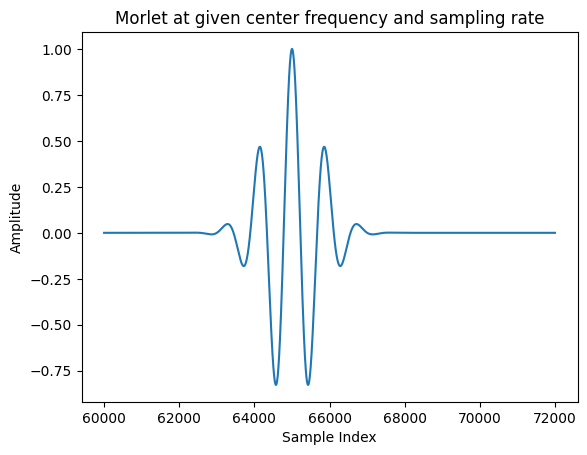

In [241]:
crop = [5000, 8_000]
plt.plot(data_cleaned['time'][idx][crop[0]:crop[1]], x[crop[0]:crop[1]])
plt.title('Morlet at given center frequency and sampling rate')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

In [223]:
# FFT to frequency domain
X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(len(x), d=1/fs)   # matches X's bins

In [224]:
r_f = stack_dict['r'][0]
t_f = stack_dict['t'][0]

# 3) Multiply spectrazzzz
Y_reflected = X * r_f
Y_transmitted = X * t_f

# 4) IFFT back to time domain
y_reflected = np.fft.irfft(Y_reflected, n=len(x))
y_transmitted = np.fft.irfft(Y_transmitted, n=len(x))

In [238]:
stack_dict['r']

array([ 0.31517066+0.26879192j,  0.48932135+0.18808272j,
        0.46841309+0.21315873j,  0.41792083-0.18569138j,
        0.15038449-0.35130868j, -0.27150739-0.16252369j,
       -0.26147568-0.2012884j , -0.164828  +0.19315569j,
       -0.19278687+0.16200728j,  0.28950267+0.10813384j,
        0.41662746-0.18960819j,  0.23162226-0.52575201j,
        0.26048998-0.51830737j, -0.05485269-0.47323639j,
       -0.02531416-0.49056206j,  0.04184021+0.49560523j,
        0.94362284+0.21580109j,  0.94786123+0.20102592j,
        0.93497193+0.16833698j])

In [ ]:
def plot_reflected_transmitted(idx):
    plt.figure(figsize=(8, 5), dpi=300)
    plt.plot(data_cleaned['time'][idx][crop[0]:crop[1]], y_reflected[crop[0]:crop[1]], label='Reflected')
    plt.plot(data_cleaned['time'][idx][crop[0]:crop[1]], y_transmitted[crop[0]:crop[1]], label='Transmitted')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Ultrasonic Pulse Propagation, layer index: {idx}')
    plt.legend()
    
idx_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(layer_props_ij)-1,
    step=1,
    description='Layer Index:',
)

interact(plot_reflected_transmitted, idx=idx_slider)

interactive(children=(IntSlider(value=0, description='Layer Index:', max=20), Output()), _dom_classes=('widget…

<function __main__.plot_reflected_transmitted(idx)>

--------------------------------------------------------------------------
Vectorizing over a whole scan
--------------------------------------------------------------------------
- presence_mask : (n_layers, ny, nx) bool array from your waveform analysis
- thickness_map : (n_layers, ny, nx) float array, NaN where no local
                    measurement (falls back to table nominal d)

In [ ]:

n_layers = len(base_layer_props)
ny, nx = presence_mask.shape[1:]
R_map = np.zeros((ny, nx))
T_map = np.zeros((ny, nx))
for i in range(ny):
    for j in range(nx):
        present = [bool(presence_mask[k, i, j]) for k in range(n_layers)]
        props = [
            dict(base_layer_props[k],
                 d=(thickness_map[k, i, j] if not np.isnan(thickness_map[k, i, j])
                    else base_layer_props[k]['d']))
            for k in range(n_layers)
        ]
        M = build_stack_matrix(props, present, f0)
        M11, M12, M21, M22 = M[0,0], M[0,1], M[1,0], M[1,1]
        denom = M11*ZL + M12 + M21*Z0*ZL + M22*Z0
        r = (M11*ZL + M12 - M21*Z0*ZL - M22*Z0) / denom
        t = 2*ZL / denom
        R_map[i, j] = abs(r)**2
        T_map[i, j] = (Z0/ZL) * abs(t)**2

In [ ]:
from tmm_core import coh_tmm, unpolarized_RT, ellips, position_resolved, find_in_structure_with_inf

In [ ]:
degree = pi/180

In [ ]:
# list of layer thicknesses in nm
d_list = [inf,100,300,inf]
# list of refractive indices
n_list = [1,2.2,3.3+0.3j,1]

# list of wavenumbers to plot in nm^-1
ks=linspace(0.0001,.01,num=400) # k = 2π/λ, so this corresponds to wavelengths of 100 nm to 100 μm
# ω = 2πf = 2π/T
# v (phase velocity) = ω/k
# v (phase velocity) and n (refractive index) are related by v=c/n, where c is the speed of light in vacuum.

# initialize lists of y-values to plot
Rnorm=[] 
R45=[]
for k in ks:
    # For normal incidence, s and p polarizations are identical.
    # I arbitrarily decided to use 's'.
    Rnorm.append(coh_tmm('s',n_list, d_list, 0, 1/k)['R'])
    R45.append(unpolarized_RT(n_list, d_list, 45*degree, 1/k)['R'])
kcm = ks * 1e7 #ks in cm^-1 rather than nm^-1
plt.figure()
plt.plot(kcm,Rnorm,'blue',kcm,R45,'purple')
plt.xlabel('k (cm$^{-1}$)')
plt.ylabel('Fraction reflected')
plt.title('Reflection of unpolarized light at 0$^\circ$ incidence (blue), '
            '45$^\circ$ (purple)');

In [ ]:
import numpy as np
import torch
from tmm_fast import coh_tmm as tmm

wl = np.linspace(400, 1200, 800) * (10**(-9))
theta = np.linspace(0, 45, 45) * (np.pi/180)
mode = 'T'
num_layers = 4
num_stacks = 128

#create m
M = np.ones((num_stacks, num_layers, wl.shape[0]))
for i in range(1, M.shape[1]-1):
    if np.mod(i, 2) == 1:
        M[:, i, :] *= 1.46
    else:
        M[:, i, :] *= 2.56

#create t
max_t = 150 * (10**(-9))
min_t = 10 * (10**(-9))
T = (max_t - min_t) * np.random.uniform(0, 1, (M.shape[0], M.shape[1])) + min_t
T[:, 0] = np.inf
T[:, -1] = np.inf

#tmm:
O = tmm('s', M, T, theta, wl, device='cpu')

print(':)')
